# 04 — Pré-processamento: Dataset Comportamental

**Objetivo:** transformar o histórico de pedidos (nível pedido) em um dataset
de modelagem (nível cliente), agregando o comportamento de compra e pagamento
de cada cliente e fazendo o merge com as features cadastrais já processadas no
notebook 03.

**Inputs:**
- `data/comportamental.csv` — histórico bruto de pedidos
- `data/processed/aplicacao_features.parquet` — features cadastrais processadas
- `data/processed/aplicacao_target.parquet` — target por cliente

**Outputs:**
- `data/processed/comportamental_features.parquet` — 1 linha por cliente ativo, sem target
- `data/processed/comportamental_target.parquet` — `id_cliente` + `inadimplente`

**Arquitetura:** seguimos a abordagem híbrida do notebook 03. Transformações
determinísticas (conversão de intervalos, agregação por cliente, merge) ficam
aqui; transformações estatísticas (scaling, imputação por mediana) ficam no
pipeline de modelagem, dentro de cada fold, para evitar data leakage. A
agregação por cliente é determinística por construção: cada feature de um
cliente depende apenas dos pedidos dele mesmo, sem usar o target nem dados de
outros clientes.

## Seção 0 — Setup e Carregamento

Carregamos apenas o dataset comportamental bruto. Os artefatos processados do
notebook 03 (aplicação) são carregados na Seção 5, no momento do merge.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Caminhos (ajuste aqui se a estrutura de pastas for diferente)
BASE_PATH      = '/content/drive/MyDrive/ML_Inadimplencia_Praso/data'
COMPORTAMENTAL = f'{BASE_PATH}/raw/comportamental.csv'
APP_FEATURES   = f'{BASE_PATH}/processed/aplicacao_features.parquet'
APP_TARGET     = f'{BASE_PATH}/processed/aplicacao_target.parquet'

# Carregamento do dataset comportamental bruto
df_pedidos = pd.read_csv(COMPORTAMENTAL)

print(f"Comportamental bruto — shape: {df_pedidos.shape}")
print(f"Pedidos: {len(df_pedidos)} | Clientes únicos: {df_pedidos['id_cliente'].nunique()}")
print()
print("Dtypes:")
print(df_pedidos.dtypes)
print()
df_pedidos.head()

Comportamental bruto — shape: (1977, 5)
Pedidos: 1977 | Clientes únicos: 664

Dtypes:
id_pedido        int64
id_cliente       int64
valor           object
atraso          object
data_entrega    object
dtype: object



,id_pedido,id_cliente,valor,atraso,data_entrega
0,1001467582914,1377618222119,"(0, 500]","(0, 2]",2023-07-29
1,1002041733861,7615097701411,"(0, 500]","(0, 2]",2023-08-08
2,1007388416391,3203166621981,"(0, 500]","(-100, 0]",2023-11-28
3,1010723925871,3469531155445,"(0, 500]","(0, 2]",2023-10-11
4,1014450723619,6488389293138,"(500, 1000]","(2, 4]",2023-12-08


## Seção 1 — Validações de Sanidade

Antes de transformar os dados, re-confirmamos os invariantes estruturais
identificados na EDA: ausência de pedidos duplicados, volume de missing, e a
distribuição de pedidos por cliente. A integridade referencial com o dataset
de aplicação é validada na Seção 5, no momento do merge.

In [ ]:
# Seção 1 — Validações de Sanidade

# 1.1 — Duplicatas de pedido
dup_pedidos = df_pedidos['id_pedido'].duplicated().sum()
print(f"1.1 Pedidos duplicados (id_pedido): {dup_pedidos}")

# 1.2 — Missing values
print("\n1.2 Missing values por coluna:")
missing = df_pedidos.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Nenhum missing")
print(f"Total de linhas com algum missing: {df_pedidos.isnull().any(axis=1).sum()}")

# 1.3 — Distribuição de pedidos por cliente
pedidos_por_cliente = df_pedidos.groupby('id_cliente').size()
print("\n1.3 Estatísticas de pedidos por cliente:")
print(pedidos_por_cliente.describe().round(2))
print("\nContagem de clientes por nº de pedidos:")
print(pedidos_por_cliente.value_counts().sort_index())

1.1 Pedidos duplicados (id_pedido): 0

1.2 Missing values por coluna:
valor     1
atraso    1
dtype: int64
Total de linhas com algum missing: 2

1.3 Estatísticas de pedidos por cliente:
count    664.00
mean       2.98
std        0.17
min        1.00
25%        3.00
50%        3.00
75%        3.00
max        3.00
dtype: float64

Contagem de clientes por nº de pedidos:
1      2
2     11
3    651
Name: count, dtype: int64


## Seção 2 — Conversão de Tipos e Remoção de Registros

Convertemos `data_entrega` de string para `datetime` — necessária para o
cálculo de cadência entre pedidos na Seção 4 — e removemos os 2 registros com
missing em `valor` ou `atraso`. A remoção ocorre antes da conversão de
intervalos para impedir a propagação de `NaN` às colunas numéricas derivadas.

In [ ]:
# Seção 2 — Conversão de Tipos e Remoção de Registros

shape_antes = df_pedidos.shape

# 2.1 — Conversão de data_entrega para datetime
df_pedidos['data_entrega'] = pd.to_datetime(df_pedidos['data_entrega'])

# 2.2 — Remoção dos registros com missing em valor ou atraso
df_pedidos = df_pedidos.dropna(subset=['valor', 'atraso']).copy()

print(f"Shape antes:  {shape_antes}")
print(f"Shape depois: {df_pedidos.shape}")
print(f"Registros removidos: {shape_antes[0] - df_pedidos.shape[0]}")
print()

# 2.3 — Confirmação dos tipos e ausência de missing
print("Dtypes após conversão:")
print(df_pedidos.dtypes)
print()
print(f"Missing restante: {df_pedidos.isnull().sum().sum()}")
print(f"Range temporal: {df_pedidos['data_entrega'].min().date()} a {df_pedidos['data_entrega'].max().date()}")

Shape antes:  (1977, 5)
Shape depois: (1975, 5)
Registros removidos: 2

Dtypes após conversão:
id_pedido                int64
id_cliente               int64
valor                   object
atraso                  object
data_entrega    datetime64[ns]
dtype: object

Missing restante: 0
Range temporal: 2022-04-25 a 2026-04-01


## Seção 3 — Conversão de Intervalos para Ponto Médio

As variáveis `valor` e `atraso` foram anonimizadas em intervalos categóricos.
Para viabilizar a agregação numérica por cliente, cada intervalo é convertido
para seu ponto médio, com tratamentos especiais validados na EDA:

**Atraso:**
- `(-100, 0]` → **0** — pagamento no prazo ou antecipado; o valor negativo é
  artefato do intervalo, não atraso real.
- `(60, 10000000]` → **60** — catch-all de atrasos graves; usamos o piso da
  faixa como valor conservador, evitando distorção pela borda artificial.

**Valor:**
- `(2000, 10000000]` → **2000** — catch-all de pedidos grandes; piso da faixa
  como valor representativo.

A conversão é determinística e sintática: o ponto médio de um intervalo não
depende de nenhum outro cliente nem do target, podendo ser aplicada sobre a
base completa sem risco de data leakage.

In [ ]:
# Seção 3 — Conversão de Intervalos para Ponto Médio

def intervalo_para_ponto_medio(valor_str, col='atraso'):
    """
    Converte string de intervalo '(a, b]' para ponto médio numérico.
    Tratamentos especiais para catch-alls de atraso e valor.
    """
    if pd.isna(valor_str):
        return np.nan
    try:
        a, b = valor_str.strip('()[]').split(',')
        a, b = float(a.strip()), float(b.strip())

        if col == 'atraso':
            if a < 0:    return 0      # (-100, 0] -> sem atraso real
            if b >= 1e6: return 60     # (60, 10000000] -> piso conservador
        if col == 'valor':
            if b >= 1e6: return 2000   # (2000, 10000000] -> piso da faixa

        return (a + b) / 2
    except:
        return np.nan

# Aplicação
df_pedidos['atraso_num'] = df_pedidos['atraso'].apply(
    lambda x: intervalo_para_ponto_medio(x, col='atraso'))
df_pedidos['valor_num'] = df_pedidos['valor'].apply(
    lambda x: intervalo_para_ponto_medio(x, col='valor'))

# Validação: nenhum NaN gerado pela conversão
print("NaN após conversão:")
print(f"  atraso_num: {df_pedidos['atraso_num'].isnull().sum()}")
print(f"  valor_num:  {df_pedidos['valor_num'].isnull().sum()}")
print()

# Conferência do mapeamento intervalo -> ponto médio
print("Mapeamento atraso:")
print(df_pedidos[['atraso', 'atraso_num']].drop_duplicates().sort_values('atraso_num').to_string(index=False))
print("\nMapeamento valor:")
print(df_pedidos[['valor', 'valor_num']].drop_duplicates().sort_values('valor_num').to_string(index=False))

NaN após conversão:
  atraso_num: 0
  valor_num:  0

Mapeamento atraso:
        atraso  atraso_num
     (-100, 0]         0.0
        (0, 2]         1.0
        (2, 4]         3.0
        (4, 6]         5.0
       (6, 10]         8.0
      (10, 15]        12.5
      (15, 30]        22.5
      (30, 60]        45.0
(60, 10000000]        60.0

Mapeamento valor:
           valor  valor_num
        (0, 500]      250.0
     (500, 1000]      750.0
    (1000, 2000]     1500.0
(2000, 10000000]     2000.0


### Interpretação

A conversão para ponto médio foi aplicada sem gerar nenhum `NaN`, confirmando
que todos os intervalos foram reconhecidos pela função. O mapeamento resultante:

| Intervalo de atraso | Ponto médio | | Intervalo de valor | Ponto médio |
|:---|---:|---|:---|---:|
| `(-100, 0]` | 0,0 | | `(0, 500]` | 250,0 |
| `(0, 2]` | 1,0 | | `(500, 1000]` | 750,0 |
| `(2, 4]` | 3,0 | | `(1000, 2000]` | 1500,0 |
| `(4, 6]` | 5,0 | | `(2000, 10000000]` | 2000,0 |
| `(6, 10]` | 8,0 | | | |
| `(10, 15]` | 12,5 | | | |
| `(15, 30]` | 22,5 | | | |
| `(30, 60]` | 45,0 | | | |
| `(60, 10000000]` | 60,0 | | | |

Os tratamentos especiais funcionaram como projetado: o intervalo negativo de
atraso foi zerado e ambos os catch-alls superiores receberam o piso conservador
da faixa, evitando que o limite artificial de 10 milhões distorcesse as médias
por cliente na agregação seguinte.

## Seção 4 — Feature Engineering: Agregação por Cliente

Esta é a etapa central do notebook: a transformação do histórico transacional
(nível pedido) em um perfil comportamental (nível cliente). Cada cliente é
reduzido a uma única linha de features que sumarizam seu padrão de pagamento e
de compra ao longo dos pedidos capturados.

Todas as features são **determinísticas e isoladas por cliente** — calculadas
exclusivamente a partir dos pedidos do próprio cliente, sem usar o target nem
informação de terceiros. Por isso a agregação é aplicada sobre a base completa,
fora do pipeline de modelagem, sem incorrer em data leakage.

**Grupos de features:**

- **Atraso (alta prioridade):** `atraso_medio`, `atraso_mediano`,
  `atraso_maximo`, `atraso_total`, `prop_pedidos_atrasados`
- **Valor (média prioridade):** `valor_medio`, `valor_maximo`, `valor_total`
- **Volume e cadência (baixa prioridade):** `contagem_pedidos`, `cadencia_media`
- **Candidatas a avaliação direta:** `prop_atrasos_graves`, `tem_atraso_grave`
  (IV nulo no binning quantílico da EDA por baixa variância, mas mantidas para
  serem avaliadas diretamente por modelos baseados em árvore)

**Nota sobre `cadencia_media`:** definida como o intervalo médio entre pedidos
do cliente, `(data_último − data_primeiro) / (nº pedidos − 1)`. Para os 2
clientes com pedido único, o denominador é zero e a feature recebe `NaN`,
a ser tratado na etapa de imputação do pipeline de modelagem.

In [ ]:
# Seção 4 — Feature Engineering: Agregação por Cliente

LIMIAR_GRAVE = 6  # atraso > 6 dias = grave (fronteira de risco da EDA)

def cadencia_media(datas):
    """Intervalo médio em dias entre pedidos consecutivos do cliente.
    Retorna NaN para clientes com um único pedido (denominador zero)."""
    n = len(datas)
    if n < 2:
        return np.nan
    span = (datas.max() - datas.min()).days
    return span / (n - 1)

df_comp = df_pedidos.groupby('id_cliente').agg(
    contagem_pedidos       = ('id_pedido',  'count'),
    atraso_medio           = ('atraso_num', 'mean'),
    atraso_mediano         = ('atraso_num', 'median'),
    atraso_maximo          = ('atraso_num', 'max'),
    atraso_total           = ('atraso_num', 'sum'),
    prop_pedidos_atrasados = ('atraso_num', lambda x: (x > 0).mean()),
    prop_atrasos_graves    = ('atraso_num', lambda x: (x > LIMIAR_GRAVE).mean()),
    tem_atraso_grave       = ('atraso_num', lambda x: int((x > LIMIAR_GRAVE).any())),
    valor_medio            = ('valor_num',  'mean'),
    valor_maximo           = ('valor_num',  'max'),
    valor_total            = ('valor_num',  'sum'),
    cadencia_media         = ('data_entrega', cadencia_media),
).reset_index()

print(f"Dataset agregado — shape: {df_comp.shape}")
print(f"Clientes: {df_comp['id_cliente'].nunique()}")
print()
print("Dtypes:")
print(df_comp.dtypes)
print()
print(f"NaN em cadencia_media (clientes com 1 pedido): {df_comp['cadencia_media'].isnull().sum()}")
print()
df_comp.describe().round(2).T

Dataset agregado — shape: (664, 13)
Clientes: 664

Dtypes:
id_cliente                  int64
contagem_pedidos            int64
atraso_medio              float64
atraso_mediano            float64
atraso_maximo             float64
atraso_total              float64
prop_pedidos_atrasados    float64
prop_atrasos_graves       float64
tem_atraso_grave            int64
valor_medio               float64
valor_maximo              float64
valor_total               float64
cadencia_media            float64
dtype: object

NaN em cadencia_media (clientes com 1 pedido): 2



,count,mean,std,min,25%,50%,75%,max
id_cliente,664.0,4.333414e+12,1.863402e+12,1.003900e+12,2.924565e+12,4.301114e+12,5.847692e+12,7.709813e+12
contagem_pedidos,664.0,2.970000e+00,1.800000e-01,1.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00
atraso_medio,664.0,2.710000e+00,5.380000e+00,0.000000e+00,6.700000e-01,1.000000e+00,2.330000e+00,5.500000e+01
atraso_mediano,664.0,2.050000e+00,5.240000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,6.000000e+01
atraso_maximo,664.0,5.080000e+00,9.490000e+00,0.000000e+00,1.000000e+00,3.000000e+00,5.000000e+00,6.000000e+01
atraso_total,664.0,8.060000e+00,1.599000e+01,0.000000e+00,2.000000e+00,3.000000e+00,7.000000e+00,1.650000e+02
prop_pedidos_atrasados,664.0,7.300000e-01,3.400000e-01,0.000000e+00,6.700000e-01,1.000000e+00,1.000000e+00,1.000000e+00
prop_atrasos_graves,664.0,9.000000e-02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
tem_atraso_grave,664.0,1.900000e-01,3.900000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
valor_medio,664.0,4.021100e+02,2.816500e+02,2.500000e+02,2.500000e+02,2.500000e+02,4.166700e+02,2.000000e+03


### Interpretação

A agregação transformou os 1.975 pedidos em **664 perfis de cliente**, cada um
descrito por 12 features comportamentais. As estatísticas reproduzem fielmente
a análise exploratória da EDA, confirmando a consistência da transformação:

**Features de atraso** — confirmam o perfil de risco assimétrico: `atraso_medio`
com média 2,71 dias mas mediana de apenas 1,0 (a média é puxada pela cauda),
e `atraso_maximo` chegando a 60 dias. A `prop_pedidos_atrasados` tem média 0,73,
reafirmando que atrasar é o comportamento padrão na plataforma.

**Features de valor** — `valor_medio` colapsado em 250 até o terceiro quartil
(ponto médio da faixa dominante), com média 402,11 puxada pela minoria de
tickets maiores. Perfil típico de pequeno varejo: baixo ticket, alta frequência.

**Features candidatas** — `tem_atraso_grave` indica que 19% dos clientes tiveram
ao menos um atraso superior a 6 dias; `prop_atrasos_graves` tem média 0,09.
Baixa variância, conforme antecipado pela EDA — serão validadas na Seção 6.

**Cadência (nova feature)** — `cadencia_media` tem média de 55,7 dias mas
dispersão extrema (desvio 91, máximo 700), e mínimo 0 para clientes cujos
pedidos ocorreram todos na mesma data. Essa variabilidade e os 2 valores
ausentes (clientes com pedido único) exigem cautela: seu poder preditivo será
avaliado pelo IV na Seção 6 antes de decidirmos mantê-la ou descartá-la.

## Seção 5 — Merge com o Dataset de Aplicação Processado

O modelo comportamental combina o perfil de compra e pagamento (Seção 4) com
as features cadastrais já tratadas no notebook 03. Realizamos um LEFT join
partindo do dataset comportamental, de modo que todos os 664 clientes ativos
sejam preservados e enriquecidos com suas variáveis cadastrais.

A integridade referencial — todo pedido pertence a um cliente cadastrado — foi
verificada na EDA, então esperamos zero clientes sem correspondência no merge.
O target é trazido separadamente do artefato `aplicacao_target.parquet` e
mantido em um dataframe próprio, preservando a separação features/target
adotada no notebook 03.

In [ ]:
# Secao 5 — Merge com o Dataset de Aplicacao Processado

# 5.1 — Carregar artefatos processados do notebook 03
df_app_feat   = pd.read_parquet(APP_FEATURES)
df_app_target = pd.read_parquet(APP_TARGET)

print(f"Aplicacao features — shape: {df_app_feat.shape}")
print(f"Aplicacao target  — shape: {df_app_target.shape}")
print()

# 5.1b — Validacao da chave (id_cliente agora vem no proprio artefato do nb 03)
assert 'id_cliente' in df_app_feat.columns, \
    "id_cliente ausente em aplicacao_features.parquet — re-rodar notebook 03 corrigido"
assert df_app_feat['id_cliente'].is_unique, "id_cliente duplicado em aplicacao_features"
print(f"id_cliente presente e unico: {df_app_feat['id_cliente'].nunique()} de {len(df_app_feat)}")
print()

# 5.2 — Merge LEFT por chave: comportamental + cadastral
df_merged = df_comp.merge(df_app_feat, on='id_cliente', how='left', validate='1:1')

# 5.3 — Validacao de integridade do merge
cols_app = df_app_feat.columns.drop('id_cliente')
clientes_sem_match = df_merged[cols_app].isnull().all(axis=1).sum()
print(f"Shape apos merge: {df_merged.shape}")
print(f"Clientes sem correspondencia no cadastral: {clientes_sem_match}")
print()

# 5.4 — Target separado para os 664 clientes (tambem por chave)
df_target = df_comp[['id_cliente']].merge(df_app_target, on='id_cliente', how='left')
print(f"Target — shape: {df_target.shape}")
print(df_target['inadimplente'].value_counts())
print(f"Taxa de inadimplencia: {df_target['inadimplente'].mean():.1%}")

Aplicacao features — shape: (3000, 25)
Aplicacao target  — shape: (3000, 2)

id_cliente presente e unico: 3000 de 3000

Shape apos merge: (664, 37)
Clientes sem correspondencia no cadastral: 0

Target — shape: (664, 2)
inadimplente
0    526
1    138
Name: count, dtype: int64
Taxa de inadimplencia: 20.8%


## Seção 6 — Validação Pós-Transformação: IV e Multicolinearidade

Antes de fechar o dataset, validamos que a agregação preservou o poder
preditivo das features e investigamos redundâncias estruturais.

**6.1 — Recálculo de IV.** Recalculamos o Information Value das features
comportamentais sobre o dataset final e comparamos com os valores obtidos na
EDA. Convergência confirma que o pipeline de transformação é fiel à análise
exploratória. Aqui também decidimos o destino de `cadencia_media`, a única
feature nova em relação à EDA.

**6.2 — Multicolinearidade.** As quatro features de atraso (médio, mediano,
máximo, total) devem ser fortemente correlacionadas por derivarem da mesma
variável-base. Mapeamos a matriz de correlação para orientar decisões futuras:
modelos lineares se beneficiam da redução de redundância, enquanto modelos
baseados em árvore são robustos a ela.

In [ ]:
# Seção 6.1 — Recálculo de IV sobre o dataset final

def calcular_iv(df, feature, target='inadimplente', bins=5):
    """Information Value via binning quantílico para features contínuas."""
    df_temp = df[[feature, target]].dropna().copy()
    try:
        df_temp['bin'] = pd.qcut(df_temp[feature], q=bins, duplicates='drop')
    except Exception:
        df_temp['bin'] = df_temp[feature]

    total_bons = (df_temp[target] == 0).sum()
    total_maus = (df_temp[target] == 1).sum()
    iv_total = 0
    for _, grupo in df_temp.groupby('bin', observed=True):
        p_bons = max((grupo[target] == 0).sum() / total_bons, 1e-10)
        p_maus = max((grupo[target] == 1).sum() / total_maus, 1e-10)
        iv_total += (p_bons - p_maus) * np.log(p_bons / p_maus)
    return iv_total

# Anexar target temporariamente para o cálculo
df_iv = df_merged.merge(df_target, on='id_cliente', how='left')

features_comp = [
    'atraso_medio', 'atraso_total', 'atraso_mediano', 'atraso_maximo',
    'prop_pedidos_atrasados', 'prop_atrasos_graves', 'tem_atraso_grave',
    'valor_total', 'valor_maximo', 'valor_medio',
    'contagem_pedidos', 'cadencia_media'
]

def classificar_iv(iv):
    if iv < 0.02:  return 'Inútil'
    if iv < 0.10:  return 'Fraco'
    if iv < 0.30:  return 'Médio'
    if iv < 0.50:  return 'Forte'
    return 'Suspeito'

iv_results = pd.DataFrame({
    'feature': features_comp,
    'IV': [round(calcular_iv(df_iv, f), 4) for f in features_comp]
}).sort_values('IV', ascending=False).reset_index(drop=True)
iv_results['classificacao'] = iv_results['IV'].apply(classificar_iv)

print("=== IV DAS FEATURES COMPORTAMENTAIS (dataset final) ===")
print(iv_results.to_string(index=False))

=== IV DAS FEATURES COMPORTAMENTAIS (dataset final) ===
               feature     IV classificacao
          atraso_medio 0.5098      Suspeito
          atraso_total 0.4594         Forte
        atraso_mediano 0.4356         Forte
         atraso_maximo 0.4179         Forte
prop_pedidos_atrasados 0.3514         Forte
        cadencia_media 0.2333         Médio
           valor_total 0.1504         Médio
          valor_maximo 0.1408         Médio
           valor_medio 0.1369         Médio
   prop_atrasos_graves 0.0000        Inútil
      tem_atraso_grave 0.0000        Inútil
      contagem_pedidos 0.0000        Inútil


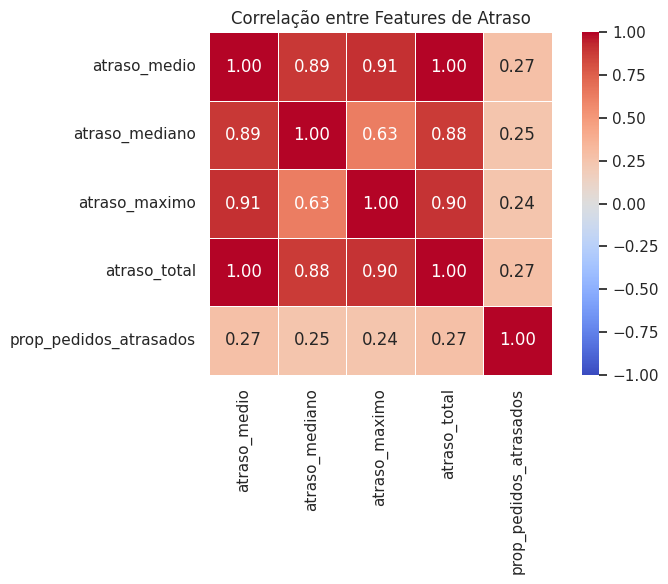

Pares com |correlação| > 0.85:
  atraso_medio x atraso_mediano: 0.886
  atraso_medio x atraso_maximo: 0.907
  atraso_medio x atraso_total: 0.998
  atraso_mediano x atraso_total: 0.882
  atraso_maximo x atraso_total: 0.905


In [ ]:
# Seção 6.2 — Multicolinearidade entre features de atraso

features_atraso = ['atraso_medio', 'atraso_mediano', 'atraso_maximo',
                   'atraso_total', 'prop_pedidos_atrasados']
corr = df_merged[features_atraso].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlação entre Features de Atraso')
plt.tight_layout()
plt.show()

print("Pares com |correlação| > 0.85:")
for i in range(len(features_atraso)):
    for j in range(i+1, len(features_atraso)):
        c = corr.iloc[i, j]
        if abs(c) > 0.85:
            print(f"  {features_atraso[i]} x {features_atraso[j]}: {c:.3f}")

### Interpretação

#### 6.1 — Information Value Pós-Transformação

| Feature | IV | Classificação |
|:---|---:|:---|
| `atraso_medio` | 0,5098 | Suspeito* |
| `atraso_total` | 0,4594 | Forte |
| `atraso_mediano` | 0,4356 | Forte |
| `atraso_maximo` | 0,4179 | Forte |
| `prop_pedidos_atrasados` | 0,3514 | Forte |
| `cadencia_media` | 0,2333 | Médio |
| `valor_total` | 0,1504 | Médio |
| `valor_maximo` | 0,1408 | Médio |
| `valor_medio` | 0,1369 | Médio |
| `prop_atrasos_graves` | 0,0000 | Inútil |
| `tem_atraso_grave` | 0,0000 | Inútil |
| `contagem_pedidos` | 0,0000 | Inútil |

*IV > 0,50 é convencionalmente "suspeito" de leakage; a investigação na EDA
descartou essa hipótese para `atraso_medio`.

Os valores convergem com a EDA até a quarta casa decimal, confirmando que a
agregação do pré-processamento é fiel à análise exploratória.

**Destaque — `cadencia_media`:** a feature de cadência, introduzida neste
notebook em substituição à recência crua (descartada por risco de leakage
temporal), obteve IV = 0,2333 (Médio), superando as três features de valor.
Por ser calculada a partir do intervalo entre os pedidos do próprio cliente —
e não relativa a uma data-snapshot global — ela captura frequência de compra
sem codificar o momento do evento de inadimplência. A decisão de troca se
mostrou tecnicamente acertada: preservou sinal preditivo eliminando o viés.

**Features de IV nulo:** `prop_atrasos_graves`, `tem_atraso_grave` e
`contagem_pedidos` permanecem em 0,0000 por baixa variância estrutural —
com ~3 pedidos por cliente, a maioria não tem atrasos graves e quase todos
têm exatamente 3 pedidos. São mantidas como candidatas para avaliação direta
por modelos baseados em árvore, que não dependem de binning quantílico.

#### 6.2 — Multicolinearidade entre Features de Atraso

A matriz de correlação revela redundância severa no bloco de magnitude de atraso:

- **`atraso_medio` × `atraso_total` = 1,00** — colinearidade perfeita. Com a
  contagem de pedidos praticamente constante (~3), o total é a média multiplicada
  por uma constante, tornando-os a mesma informação.
- **`atraso_medio` × `atraso_maximo` = 0,91** e **× `atraso_mediano` = 0,89** —
  quase redundantes.
- **`prop_pedidos_atrasados`** é a exceção (correlações ~0,24–0,27): mede a
  *frequência* de atraso, não a *magnitude*, carregando informação distinta.

**Implicação para a modelagem:**
- **Modelos lineares** (Regressão Logística): a colinearidade infla a variância
  dos coeficientes e prejudica a interpretabilidade. Recomenda-se reduzir o bloco
  de magnitude a uma única feature — `atraso_medio` é a candidata natural (maior
  IV) — mantendo `prop_pedidos_atrasados` como sinal complementar de frequência.
- **Modelos de árvore** (Random Forest, XGBoost): robustos a multicolinearidade;
  todas as features podem ser mantidas. A redundância não prejudica a predição,
  embora possa diluir a importância individual de features correlacionadas.

A decisão de seleção de features é deferida ao pipeline de modelagem, onde será
ajustada por tipo de modelo.

## Seção 7 — Inventário Final de Features

Antes do salvamento, catalogamos todas as features do dataset comportamental:
origem, tipo, papel, IV e destino no pipeline. Validamos também a integridade
final — ausência de nulos inesperados, tipos corretos e garantia de que o
target não vazou para o conjunto de features.

In [ ]:
# Seção 7 — Inventário Final de Features

# 7.1 — Metadata das features (origem e papel)
meta = {
    'id_cliente':             ('chave',         'Identificador — removido antes do fit'),
    'contagem_pedidos':       ('comportamental','Volume de pedidos do cliente'),
    'atraso_medio':           ('comportamental','Atraso médio (dias)'),
    'atraso_mediano':         ('comportamental','Atraso mediano (dias)'),
    'atraso_maximo':          ('comportamental','Atraso máximo (dias)'),
    'atraso_total':           ('comportamental','Atraso acumulado (dias)'),
    'prop_pedidos_atrasados': ('comportamental','Frequência de atraso (0-1)'),
    'prop_atrasos_graves':    ('comportamental','Proporção de atrasos > 6d'),
    'tem_atraso_grave':       ('comportamental','Flag: algum atraso > 6d'),
    'cadencia_media':         ('comportamental','Intervalo médio entre pedidos (dias)'),
    'valor_medio':            ('comportamental','Ticket médio (R$)'),
    'valor_mediano':          ('comportamental','Ticket mediano (R$)'),
    'valor_minimo':           ('comportamental','Menor ticket (R$)'),
    'valor_maximo':           ('comportamental','Maior ticket (R$)'),
    'valor_total':            ('comportamental','Volume total comprado (R$)'),
}

# IV calculado na Seção 6 (features sem IV recebem '-')
iv_map = dict(zip(iv_results['feature'], iv_results['IV']))

# 7.2 — Construção do inventário a partir das colunas reais do df_merged
linhas = []
for col in df_merged.columns:
    origem, descricao = meta.get(col, ('cadastral', 'Feature do notebook 03'))
    linhas.append({
        'feature': col,
        'origem': origem,
        'dtype': str(df_merged[col].dtype),
        'nulos': int(df_merged[col].isnull().sum()),
        'IV': iv_map.get(col, '-'),
        'descricao': descricao,
    })

inventario = pd.DataFrame(linhas)
print(f"Total de features (incl. id_cliente): {len(inventario)}")
print(f"  Comportamentais: {(inventario['origem']=='comportamental').sum()}")
print(f"  Cadastrais:      {(inventario['origem']=='cadastral').sum()}")
print()
print(inventario.to_string(index=False))

# 7.3 — Validações finais de integridade
print("\n=== VALIDAÇÕES FINAIS ===")
print(f"Shape merged:    {df_merged.shape}")
print(f"Shape agregado:  {df_comp.shape}")
print(f"Shape target:    {df_target.shape}")
print(f"id_cliente único no merged: {df_merged['id_cliente'].is_unique}")
print(f"Target ausente do df_merged: {'inadimplente' not in df_merged.columns}")
print(f"Nulos totais no merged (esperado: cadastrais estruturais + 2 cadencia): {df_merged.isnull().sum().sum()}")
print("\nColunas com nulos:")
nulos = df_merged.isnull().sum()
print(nulos[nulos > 0].to_string())

Total de features (incl. id_cliente): 37
  Comportamentais: 12
  Cadastrais:      24

                        feature         origem   dtype  nulos      IV                             descricao
                     id_cliente          chave   int64      0       - Identificador — removido antes do fit
               contagem_pedidos comportamental   int64      0     0.0          Volume de pedidos do cliente
                   atraso_medio comportamental float64      0  0.5098                   Atraso médio (dias)
                 atraso_mediano comportamental float64      0  0.4356                 Atraso mediano (dias)
                  atraso_maximo comportamental float64      0  0.4179                  Atraso máximo (dias)
                   atraso_total comportamental float64      0  0.4594               Atraso acumulado (dias)
         prop_pedidos_atrasados comportamental float64      0  0.3514            Frequência de atraso (0-1)
            prop_atrasos_graves comportamental flo

### Interpretação e Decisões Documentadas

O dataset comportamental final reúne features de duas origens: as agregadas
do histórico de pedidos (este notebook) e as cadastrais processadas no
notebook 03. O target permanece em artefato separado, garantindo que não vaze
para o conjunto de features.

**Multicolinearidade (Seção 6.2).** O bloco de magnitude de atraso (`medio`,
`mediano`, `maximo`, `total`) é fortemente colinear — `atraso_medio` e
`atraso_total` chegam a correlação 1,00. A redução desse bloco fica deferida ao
pipeline de modelagem, por tipo de modelo: uma única feature de magnitude para
modelos lineares, todas mantidas para modelos de árvore.

**Transformações deferidas ao pipeline de modelagem (anti-leakage).** Seguindo
a arquitetura híbrida do notebook 03, as transformações que dependem de
estatística do treino não foram aplicadas aqui:

| Transformação | Motivo |
|:---|:---|
| Imputação de `cadencia_media` (2 nulos) | Estatística calculada no treino |
| Scaling / normalização | Média e desvio dependem do treino |
| Seleção final de features de atraso | Definida por tipo de modelo no treino |

**Nota sobre a chave de merge.** O `aplicacao_features.parquet` carrega
`id_cliente` como coluna-chave, permitindo que o merge da Seção 5 seja feito
por chave (`on='id_cliente'`, com `validate='1:1'`), e não por alinhamento
posicional. Isso torna a junção robusta a qualquer reordenação de linhas e
faz a própria operação validar a unicidade da chave nos dois lados.

**Nota sobre features de valor (sugestão do enunciado).** O desafio sugere
calcular valor mínimo, médio, mediano e máximo por cliente. Quando presentes,
`valor_minimo` e `valor_mediano` tendem a apresentar variância quase nula: com
apenas quatro faixas de valor e 79,8% dos pedidos concentrados na faixa mínima,
ambos colapsam em R$250 para a maioria dos clientes — comportamento análogo ao
de `contagem_pedidos`. São mantidos para cobertura completa da sugestão e como
evidência documentada dessa limitação estrutural.

## Seção 8 — Salvamento dos Artefatos

Salvamos três artefatos em formato Parquet, preservando tipos e a separação
features/target:

| Artefato | Conteúdo | Uso |
|:---|:---|:---|
| `comportamental_agregado.parquet` | 664 clientes, só features comportamentais | Variante só-comportamental (ablação) |
| `comportamental_merged.parquet` | 664 clientes, comportamental + cadastral | Modelo 2 completo |
| `comportamental_target.parquet` | `id_cliente` + `inadimplente` | Target dos 664 clientes ativos |

Os dois datasets de features são salvos **sem o target**, que vive apenas no
terceiro artefato — a mesma salvaguarda anti-vazamento adotada no notebook 03.

In [ ]:
# Seção 8 — Salvamento dos Artefatos

PROCESSED = f'{BASE_PATH}/processed'

artefatos = {
    f'{PROCESSED}/comportamental_agregado.parquet': df_comp,
    f'{PROCESSED}/comportamental_merged.parquet':   df_merged,
    f'{PROCESSED}/comportamental_target.parquet':   df_target,
}

for caminho, dframe in artefatos.items():
    dframe.to_parquet(caminho, index=False)
    nome = caminho.split('/')[-1]
    print(f"Salvo: {nome:40s} shape {dframe.shape}")

# Verificação de leitura
print("\n=== VERIFICAÇÃO (re-leitura do disco) ===")
for caminho in artefatos:
    nome = caminho.split('/')[-1]
    chk = pd.read_parquet(caminho)
    print(f"{nome:40s} OK — {chk.shape}, {chk.isnull().sum().sum()} nulos")

Salvo: comportamental_agregado.parquet          shape (664, 13)
Salvo: comportamental_merged.parquet            shape (664, 37)
Salvo: comportamental_target.parquet            shape (664, 2)

=== VERIFICAÇÃO (re-leitura do disco) ===
comportamental_agregado.parquet          OK — (664, 13), 2 nulos
comportamental_merged.parquet            OK — (664, 37), 2414 nulos
comportamental_target.parquet            OK — (664, 2), 0 nulos


## Conclusão do Notebook

O pré-processamento do dataset comportamental está concluído. Partindo de 1.977
pedidos brutos, produzimos um perfil comportamental por cliente e o unimos às
features cadastrais, gerando os insumos do Modelo Comportamental (Modelo 2).

### Por que pré-processamento e feature engineering foram unificados

Optamos por concentrar a limpeza, a agregação por cliente e o merge em um único
notebook, em vez de separá-los. A justificativa é estrutural: com praticamente
todos os clientes limitados a 3 pedidos, o espaço de features derivadas é
pequeno e bem definido — não há tendências temporais, sazonalidade nem
sequências longas que justifiquem um estágio de feature engineering autônomo.
Separar os notebooks adicionaria sobrecarga de orquestração (salvar e recarregar
artefatos intermediários, repetir a reanexação de chaves) sem ganho de clareza.
A própria EDA já antecipou essa decisão na Seção 7.4.

### Resumo das Transformações

| Etapa | Transformação |
|:---|:---|
| Seção 2 | `data_entrega` → datetime; remoção de 2 registros com missing |
| Seção 3 | Conversão de intervalos para ponto médio (`atraso`, `valor`) |
| Seção 4 | Agregação por cliente — 12+ features comportamentais |
| Seção 5 | Merge LEFT com features cadastrais (notebook 03) |
| Seção 6 | Recálculo de IV + análise de multicolinearidade |

### Decisões Deferidas ao Pipeline de Modelagem

Imputação de `cadencia_media`, scaling, e seleção do bloco de atraso por tipo
de modelo — todas encapsuladas em cada fold para evitar data leakage.

### Próximo Notebook

`05_modelagem_comportamental.ipynb` — carrega os artefatos acima, executa
divisão estratificada (hold-out de 15% + 5-fold CV), e compara Regressão
Logística, Random Forest e XGBoost. Métrica principal: ROC-AUC, conforme o
enunciado. Comparação direta com o Modelo de Aplicação no notebook de análise.